# Example Panel MXL Model Estimations

## Disclaimer

This notebook is a simplified code template that complements the thesis by illustrating the estimation method. It is not the final code used in the research project. This final code can not be used as it contains data owned by Eneco.

The pilot choice sets used here did not include certainty in payback time as an attribute.

Certainty in payback time was only included in the final model and final choice data. The final data was purchased by Eneco and remains Eneco property, and therefore is not published in this repository.

This notebook only uses Pilot_Results_Update.csv and includes:
- formatting Pilot_Results_Update for wide panel MXL estimation,
- panel MXL estimation,
- relative importance using Lancsar,
- latent class estimation,
- ASC distribution,
- sensitivity analysis.

Each code block is run once as an example.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import biogeme.database as db
import biogeme.biogeme as bio
from biogeme import models
from biogeme.database.panel import PanelDatabase
from biogeme.expressions import Beta, Variable, Draws, MonteCarlo, log, exp, MultipleSum

# 1) Format Pilot_Results_Update to long + wide format for panel estimation
raw = pd.read_csv(Path("Pilot_Results_Update.csv"), sep=";")
backup_map = {"One socket": 0, "Full house": 1}

# Numeric panel ID for Biogeme
id_numeric = raw["ID"].astype(str).astype("category").cat.codes + 1

long_df = pd.DataFrame(
    {
        "ID": id_numeric.astype(int),
        "TASK_ID": raw["set"].astype(int),
        "COST1": raw["A_cost"],
        "PAYBACK1": raw["A_payback"],
        "SELFCONSUMPTION1": raw["A_selfconsumption"],
        "BACKUP1": raw["A_backup"].map(backup_map).astype(int),
        "COST2": raw["B_cost"],
        "PAYBACK2": raw["B_payback"],
        "SELFCONSUMPTION2": raw["B_selfconsumption"],
        "BACKUP2": raw["B_backup"].map(backup_map).astype(int),
        "CHOICE": raw["Choice"].astype(int) + 1,
        "AV1": 1,
        "AV2": 1,
        "AV3": 1,
    }
)

biodata_long = db.Database("pilot_results_long", long_df)
biodata_long.panel("ID")
panel_db = PanelDatabase(biodata_long, "ID")
wide_df, obs_per_ind = panel_db.flatten_database(missing_data=np.nan)
biodata_wide = db.Database("pilot_results_wide", wide_df)

print("Long rows:", len(long_df))
print("Individuals (wide rows):", len(wide_df))
print("Choice tasks per individual:", int(obs_per_ind))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Long rows: 512
Individuals (wide rows): 64
Choice tasks per individual: 8


c:\python-projects\thesis\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# 2) Panel MXL estimation (one dataset)
def build_panel_variables(obs):
    COST1 = {q: Variable(f"COST1__panel__{q+1:02d}") for q in range(obs)}
    PAYBACK1 = {q: Variable(f"PAYBACK1__panel__{q+1:02d}") for q in range(obs)}
    SELF1 = {q: Variable(f"SELFCONSUMPTION1__panel__{q+1:02d}") for q in range(obs)}
    BACKUP1 = {q: Variable(f"BACKUP1__panel__{q+1:02d}") for q in range(obs)}

    COST2 = {q: Variable(f"COST2__panel__{q+1:02d}") for q in range(obs)}
    PAYBACK2 = {q: Variable(f"PAYBACK2__panel__{q+1:02d}") for q in range(obs)}
    SELF2 = {q: Variable(f"SELFCONSUMPTION2__panel__{q+1:02d}") for q in range(obs)}
    BACKUP2 = {q: Variable(f"BACKUP2__panel__{q+1:02d}") for q in range(obs)}

    CHOICE = {q: Variable(f"CHOICE__panel__{q+1:02d}") for q in range(obs)}
    AV1 = {q: Variable(f"AV1__panel__{q+1:02d}") for q in range(obs)}
    AV2 = {q: Variable(f"AV2__panel__{q+1:02d}") for q in range(obs)}
    AV3 = {q: Variable(f"AV3__panel__{q+1:02d}") for q in range(obs)}
    return COST1, PAYBACK1, SELF1, BACKUP1, COST2, PAYBACK2, SELF2, BACKUP2, CHOICE, AV1, AV2, AV3


COST1, PAYBACK1, SELF1, BACKUP1, COST2, PAYBACK2, SELF2, BACKUP2, CHOICE, AV1, AV2, AV3 = build_panel_variables(obs_per_ind)

B_cost = Beta("B_cost", 0, None, None, 0)
B_payback = Beta("B_payback", 0, None, None, 0)
B_self = Beta("B_self", 0, None, None, 0)
B_backup = Beta("B_backup", 0, None, None, 0)
ASC_NO_BATT = Beta("ASC_NO_BATT", 0, None, None, 0)
sigma_ASC_NO_BATT = Beta("sigma_ASC_NO_BATT", 1, None, None, 0)
ASC_NO_BATT_rnd = ASC_NO_BATT + sigma_ASC_NO_BATT * Draws("ASC_NO_BATT_rnd", "NORMAL_HALTON2")

V = []
AV = []
for q in range(obs_per_ind):
    V.append(
        {
            1: B_cost * (COST1[q] / 1000) + B_payback * PAYBACK1[q] + B_self * SELF1[q] + B_backup * BACKUP1[q],
            2: B_cost * (COST2[q] / 1000) + B_payback * PAYBACK2[q] + B_self * SELF2[q] + B_backup * BACKUP2[q],
            3: ASC_NO_BATT_rnd,
        }
    )
    AV.append({1: AV1[q], 2: AV2[q], 3: AV3[q]})

prob_panel = 1
for q in range(obs_per_ind):
    prob_panel *= models.logit(V[q], AV[q], CHOICE[q])

logprob = log(MonteCarlo(prob_panel))
biogeme_panel = bio.BIOGEME(
    biodata_wide,
    logprob,
    number_of_draws=500,
    seed=12345,
    generate_html=False,
    generate_yaml=False,
)
biogeme_panel.model_name = "Panel MXL pilot"
panel_results = biogeme_panel.estimate()

print(panel_results.short_summary())
print(panel_results.get_beta_values())

The number of draws (500) is low. The results may not be meaningful.


Results for model Panel MXL pilot
Nbr of parameters:		6
Sample size:			64
Excluded data:			0
Final log likelihood:		-426.5504
Akaike Information Criterion:	865.1008
Bayesian Information Criterion:	878.0541

{'B_cost': -0.20454907904308237, 'B_payback': -0.21987843357173711, 'B_self': 0.04402439384456003, 'B_backup': 1.2269284628865864, 'ASC_NO_BATT': -0.5551373937938373, 'sigma_ASC_NO_BATT': 2.2930786630849433}


In [3]:
# 3) Relative importance (Lancsar-style probability impact)
def adoption_share(params, profile, n_draws=20000, seed=42):
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_draws)

    v_batt = (
        params.get("B_cost", 0.0) * (profile["cost"] / 1000)
        + params.get("B_payback", 0.0) * profile["payback"]
        + params.get("B_self", 0.0) * profile["selfconsumption"]
        + params.get("B_backup", 0.0) * profile["backup"]
    )
    v_no = params.get("ASC_NO_BATT", 0.0) + params.get("sigma_ASC_NO_BATT", 0.0) * z
    return float(np.mean(np.exp(v_batt) / (np.exp(v_batt) + np.exp(v_no))))


levels = {
    "cost": sorted(set(raw["A_cost"]) | set(raw["B_cost"])),
    "payback": sorted(set(raw["A_payback"]) | set(raw["B_payback"])),
    "selfconsumption": sorted(set(raw["A_selfconsumption"]) | set(raw["B_selfconsumption"])),
    "backup": sorted(set(raw["A_backup"].map(backup_map)) | set(raw["B_backup"].map(backup_map))),
}
baseline = {"cost": 4000, "payback": 10, "selfconsumption": 60, "backup": 0.5}
params = panel_results.get_beta_values()

rows = []
for attr in ["cost", "payback", "selfconsumption", "backup"]:
    shares = []
    for lv in levels[attr]:
        scenario = baseline.copy()
        scenario[attr] = lv
        shares.append(adoption_share(params, scenario))
    impact = max(shares) - min(shares)
    rows.append({"attribute": attr, "impact": impact})

ri = pd.DataFrame(rows)
ri["relative_importance_pct"] = 100 * ri["impact"] / ri["impact"].sum()
print(ri.sort_values("relative_importance_pct", ascending=False).to_string(index=False))

      attribute   impact  relative_importance_pct
selfconsumption 0.340704                35.790785
        payback 0.286450                30.091351
           cost 0.162414                17.061440
         backup 0.162366                17.056424


In [4]:
# 4) Latent class estimation (2 classes, one dataset)
CLASS2_INTERCEPT = Beta("CLASS2_INTERCEPT", 0, None, None, 0)
prob_c1 = 1 / (1 + exp(CLASS2_INTERCEPT))
prob_c2 = exp(CLASS2_INTERCEPT) / (1 + exp(CLASS2_INTERCEPT))

B_cost_c1 = Beta("B_cost_c1", 0, None, None, 0)
B_payback_c1 = Beta("B_payback_c1", 0, None, None, 0)
B_self_c1 = Beta("B_self_c1", 0, None, None, 0)
B_backup_c1 = Beta("B_backup_c1", 0, None, None, 0)
ASC_c1 = Beta("ASC_NO_BATT_c1", 0, None, None, 0)

B_cost_c2 = Beta("B_cost_c2", 0, None, None, 0)
B_payback_c2 = Beta("B_payback_c2", 0, None, None, 0)
B_self_c2 = Beta("B_self_c2", 0, None, None, 0)
B_backup_c2 = Beta("B_backup_c2", 0, None, None, 0)
ASC_c2 = Beta("ASC_NO_BATT_c2", 0, None, None, 0)

loglike_c1 = 0
loglike_c2 = 0
for q in range(obs_per_ind):
    v_c1 = {
        1: B_cost_c1 * (COST1[q] / 1000) + B_payback_c1 * PAYBACK1[q] + B_self_c1 * SELF1[q] + B_backup_c1 * BACKUP1[q],
        2: B_cost_c1 * (COST2[q] / 1000) + B_payback_c1 * PAYBACK2[q] + B_self_c1 * SELF2[q] + B_backup_c1 * BACKUP2[q],
        3: ASC_c1,
    }
    v_c2 = {
        1: B_cost_c2 * (COST1[q] / 1000) + B_payback_c2 * PAYBACK1[q] + B_self_c2 * SELF1[q] + B_backup_c2 * BACKUP1[q],
        2: B_cost_c2 * (COST2[q] / 1000) + B_payback_c2 * PAYBACK2[q] + B_self_c2 * SELF2[q] + B_backup_c2 * BACKUP2[q],
        3: ASC_c2,
    }
    av_q = {1: AV1[q], 2: AV2[q], 3: AV3[q]}
    loglike_c1 += models.loglogit(v_c1, av_q, CHOICE[q])
    loglike_c2 += models.loglogit(v_c2, av_q, CHOICE[q])

logprob_lc = log(prob_c1 * exp(loglike_c1) + prob_c2 * exp(loglike_c2))
biogeme_lc = bio.BIOGEME(biodata_wide, logprob_lc, generate_html=False, generate_yaml=False)
biogeme_lc.model_name = "Panel LC 2-class pilot"
lc_results = biogeme_lc.estimate()

betas_lc = lc_results.get_beta_values()
p2 = float(np.exp(betas_lc["CLASS2_INTERCEPT"]) / (1 + np.exp(betas_lc["CLASS2_INTERCEPT"])))
p1 = 1 - p2

print(lc_results.short_summary())
print({"class_1_share": p1, "class_2_share": p2})

Results for model Panel LC 2-class pilot
Nbr of parameters:		11
Sample size:			64
Excluded data:			0
Final log likelihood:		-425.6948
Akaike Information Criterion:	873.3896
Bayesian Information Criterion:	897.1373

{'class_1_share': 0.4933381834534505, 'class_2_share': 0.5066618165465495}


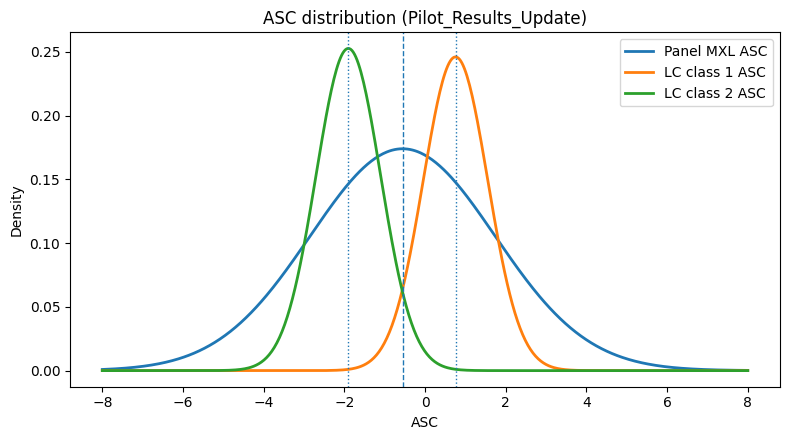

In [5]:
# 5) ASC distribution (Panel MXL vs latent classes)
def normal_pdf(x, mu, sigma):
    sigma = max(float(abs(sigma)), 1e-6)
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

panel_betas = panel_results.get_beta_values()
lc_betas = lc_results.get_beta_values()

x = np.linspace(-8, 8, 500)
panel_mu = panel_betas.get("ASC_NO_BATT", 0.0)
panel_sigma = abs(panel_betas.get("sigma_ASC_NO_BATT", 0.1))

p2 = float(np.exp(lc_betas["CLASS2_INTERCEPT"]) / (1 + np.exp(lc_betas["CLASS2_INTERCEPT"])))
p1 = 1 - p2

mu1 = lc_betas.get("ASC_NO_BATT_c1", 0.0)
mu2 = lc_betas.get("ASC_NO_BATT_c2", 0.0)

plt.figure(figsize=(8, 4.5))
plt.plot(x, normal_pdf(x, panel_mu, panel_sigma), label="Panel MXL ASC", linewidth=2)
plt.plot(x, p1 * normal_pdf(x, mu1, 0.8), label="LC class 1 ASC", linewidth=2)
plt.plot(x, p2 * normal_pdf(x, mu2, 0.8), label="LC class 2 ASC", linewidth=2)
plt.axvline(panel_mu, linestyle="--", linewidth=1)
plt.axvline(mu1, linestyle=":", linewidth=1)
plt.axvline(mu2, linestyle=":", linewidth=1)
plt.title("ASC distribution (Pilot_Results_Update)")
plt.xlabel("ASC")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

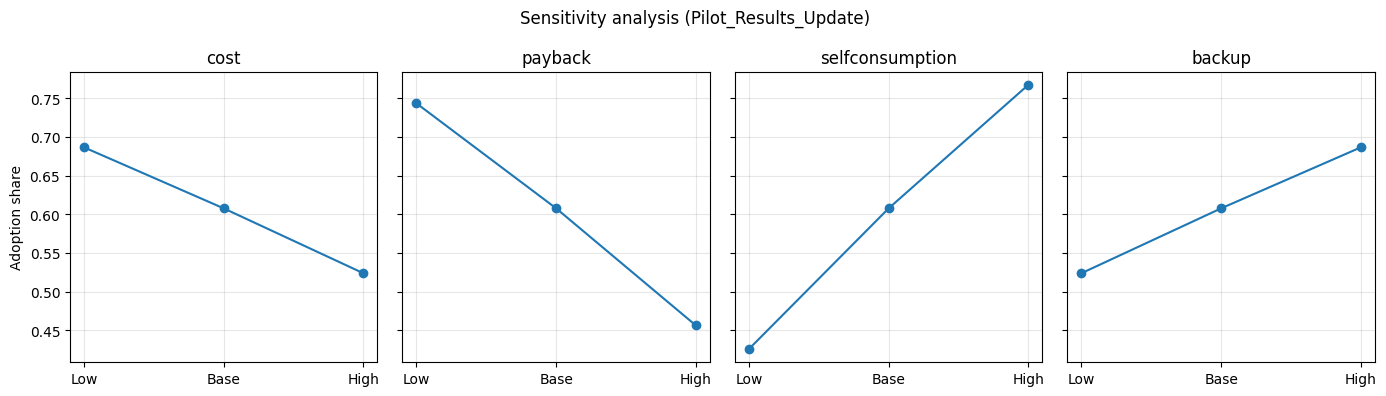

In [6]:
# 6) Sensitivity analysis (one dataset)
def adoption_share_panel(profile, n_draws=20000, seed=123):
    b = panel_results.get_beta_values()
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_draws)

    v_batt = (
        b.get("B_cost", 0.0) * (profile["cost"] / 1000)
        + b.get("B_payback", 0.0) * profile["payback"]
        + b.get("B_self", 0.0) * profile["selfconsumption"]
        + b.get("B_backup", 0.0) * profile["backup"]
    )
    v_no = b.get("ASC_NO_BATT", 0.0) + b.get("sigma_ASC_NO_BATT", 0.0) * z
    return float(np.mean(np.exp(v_batt) / (np.exp(v_batt) + np.exp(v_no))))


baseline = {"cost": 4000, "payback": 10, "selfconsumption": 60, "backup": 0.5}
settings = [
    ("cost", [1000, 4000, 7000]),
    ("payback", [5, 10, 15]),
    ("selfconsumption", [30, 60, 90]),
    ("backup", [0, 0.5, 1]),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, (attr, vals) in zip(axes, settings):
    shares = []
    for v in vals:
        profile = baseline.copy()
        profile[attr] = v
        shares.append(adoption_share_panel(profile))
    ax.plot(["Low", "Base", "High"], shares, marker="o")
    ax.set_title(attr)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Adoption share")
plt.suptitle("Sensitivity analysis (Pilot_Results_Update)")
plt.tight_layout()
plt.show()